# Fake Job Posting Detection Project

This notebook implements a machine learning solution to detect fake job postings using various classification algorithms and natural language processing techniques.

## Project Overview
- **Objective**: Build a model to classify job postings as real or fake
- **Dataset**: fake_job_postings.csv
- **Approach**: Text analysis combined with traditional ML features
- **Models**: Multiple classification algorithms comparison

## 1. Import Required Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.pipeline import Pipeline

# Natural Language Processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK data
try:
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')
    nltk.download('omw-1.4')
except:
    print("NLTK data already downloaded")

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rrrbr\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rrrbr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\rrrbr\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\rrrbr\AppData\Roaming\nltk_data...


Libraries imported successfully!


## 2. Load and Explore the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('fake_job_postings.csv')

print("Dataset shape:", df.shape)
print("\nDataset columns:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset shape: (17880, 18)

Dataset columns:
['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

First few rows:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [3]:
# Basic dataset information
print("Dataset Info:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nTarget variable distribution:")
print(df['fraudulent'].value_counts())
print("\nTarget variable distribution (percentage):")
print(df['fraudulent'].value_counts(normalize=True) * 100)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  ob

## 3. Data Preprocessing and Cleaning

In [4]:
# Create a copy for processing
df_clean = df.copy()

# Fill missing values with empty strings for text columns
text_columns = ['title', 'location', 'department', 'company_profile', 
                'description', 'requirements', 'benefits']

for col in text_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('')

# Fill missing values for categorical columns
categorical_columns = ['employment_type', 'required_experience', 'required_education', 
                      'industry', 'function']

for col in categorical_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('Not Specified')

# Boolean columns
boolean_columns = ['has_company_logo', 'has_questions', 'telecommuting']
for col in boolean_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
job_id                     0
title                      0
location                   0
department                 0
salary_range           15012
company_profile            0
description                0
requirements               0
benefits                   0
telecommuting              0
has_company_logo           0
has_questions              0
employment_type            0
required_experience        0
required_education         0
industry                   0
function                   0
fraudulent                 0
dtype: int64


In [5]:
# Text cleaning function
def clean_text(text):
    """Clean and preprocess text data"""
    if pd.isna(text) or text == '':
        return ''
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove HTML tags
    text = re.sub('<.*?>', '', text)
    
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove special characters but keep spaces and alphanumeric
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

# Apply text cleaning to relevant columns
for col in text_columns:
    if col in df_clean.columns:
        df_clean[f'{col}_clean'] = df_clean[col].apply(clean_text)

print("Text cleaning completed!")

Text cleaning completed!


## 4. Exploratory Data Analysis

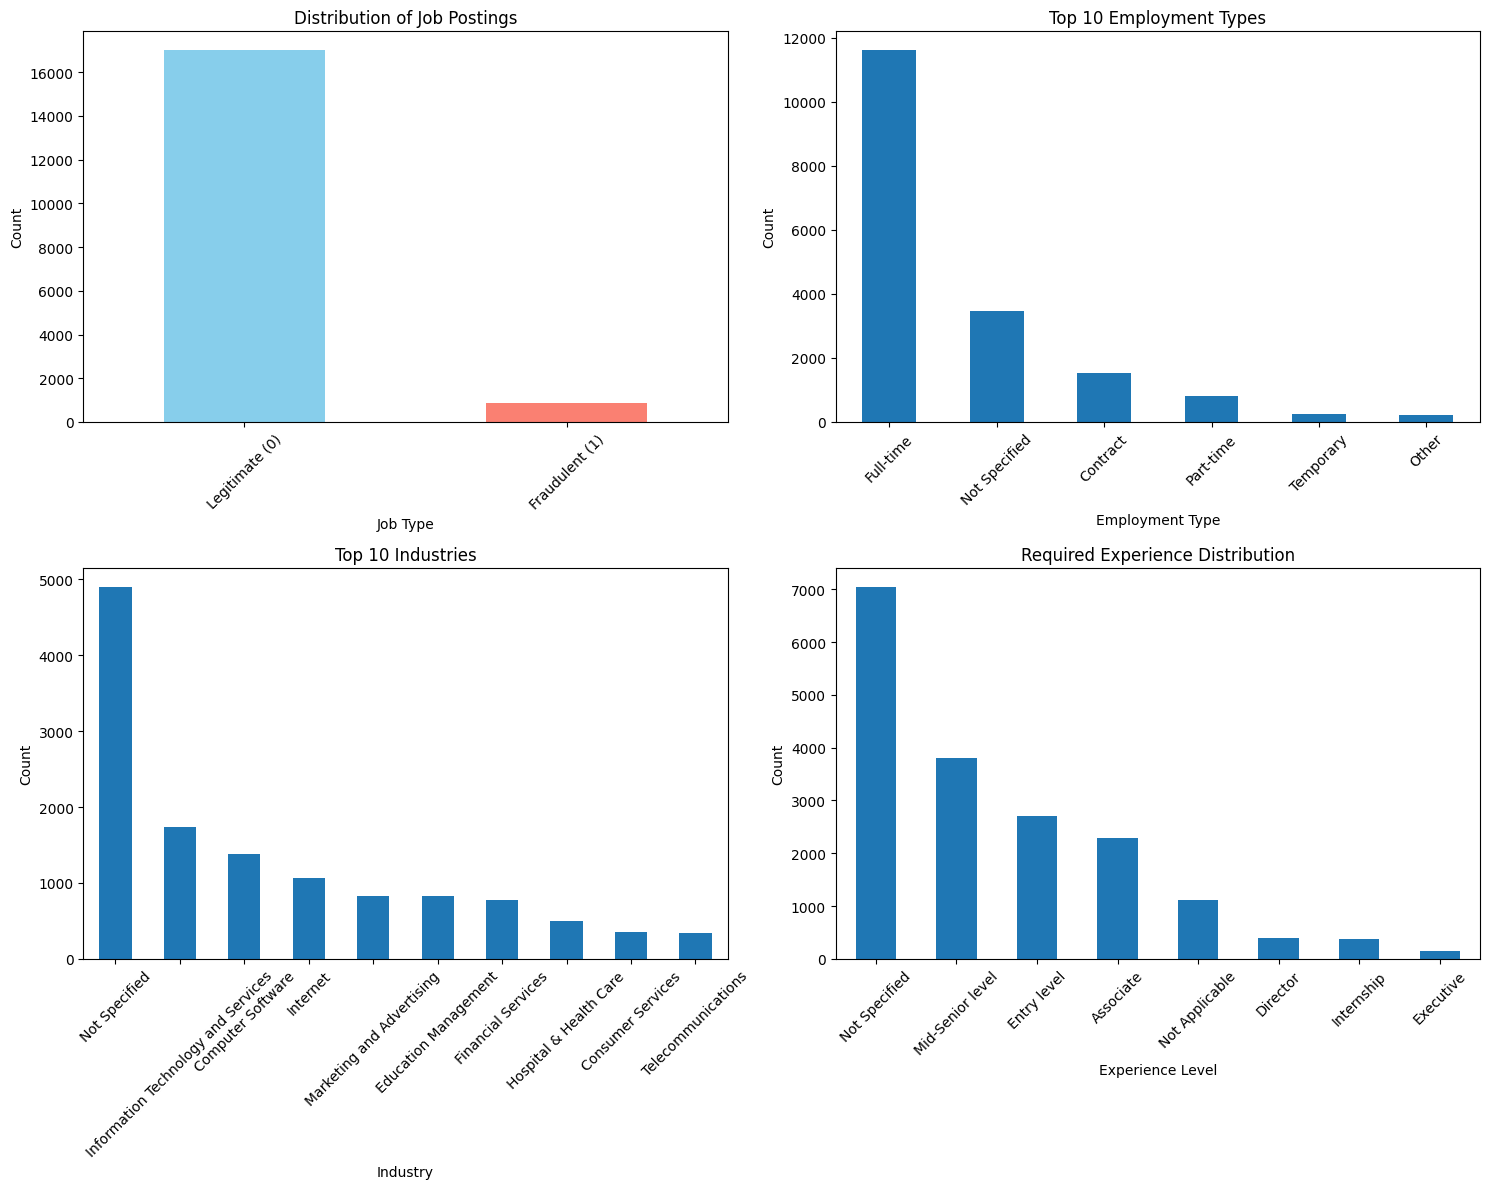

In [6]:
# Set up the plotting style
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Distribution of fraudulent vs legitimate jobs
ax1 = axes[0, 0]
df_clean['fraudulent'].value_counts().plot(kind='bar', ax=ax1, color=['skyblue', 'salmon'])
ax1.set_title('Distribution of Job Postings')
ax1.set_xlabel('Job Type')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'], rotation=45)

# 2. Employment type distribution
ax2 = axes[0, 1]
emp_counts = df_clean['employment_type'].value_counts().head(10)
emp_counts.plot(kind='bar', ax=ax2)
ax2.set_title('Top 10 Employment Types')
ax2.set_xlabel('Employment Type')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

# 3. Industry distribution
ax3 = axes[1, 0]
industry_counts = df_clean['industry'].value_counts().head(10)
industry_counts.plot(kind='bar', ax=ax3)
ax3.set_title('Top 10 Industries')
ax3.set_xlabel('Industry')
ax3.set_ylabel('Count')
ax3.tick_params(axis='x', rotation=45)

# 4. Required experience distribution
ax4 = axes[1, 1]
exp_counts = df_clean['required_experience'].value_counts().head(8)
exp_counts.plot(kind='bar', ax=ax4)
ax4.set_title('Required Experience Distribution')
ax4.set_xlabel('Experience Level')
ax4.set_ylabel('Count')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

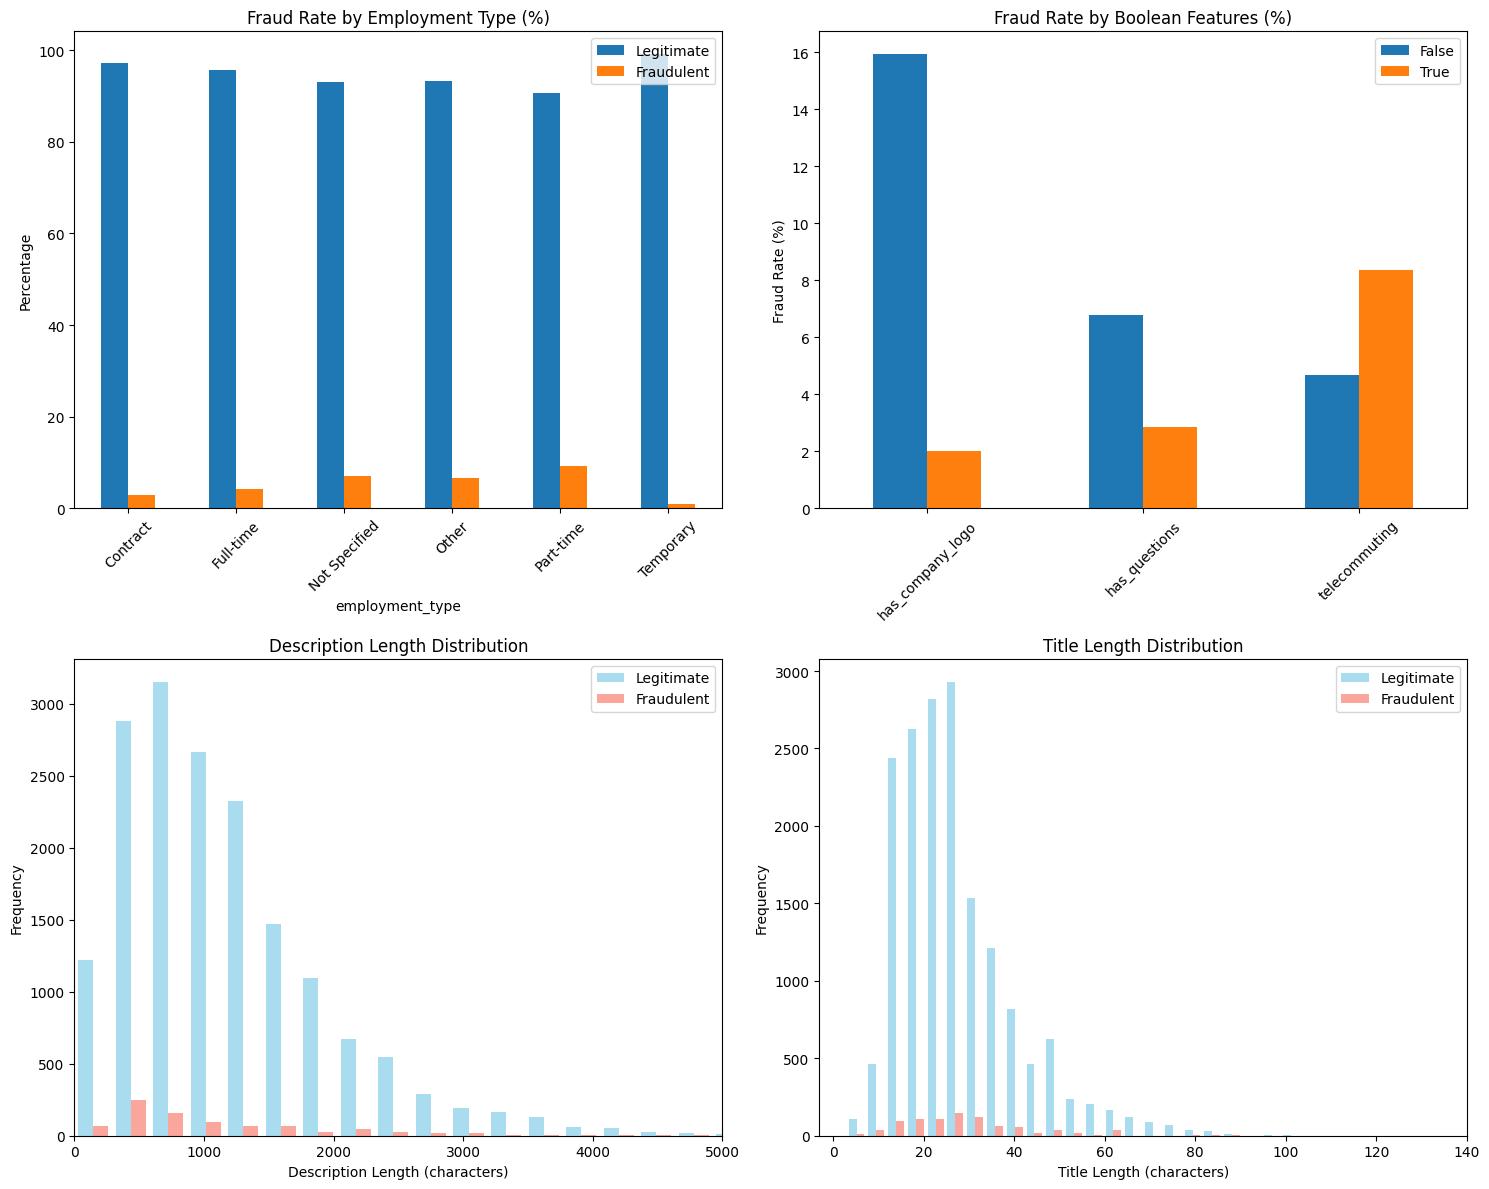

In [7]:
# Analyze fraudulent jobs by different categories
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Fraudulent jobs by employment type
fraud_emp = pd.crosstab(df_clean['employment_type'], df_clean['fraudulent'], normalize='index') * 100
fraud_emp.plot(kind='bar', ax=axes[0, 0], stacked=False)
axes[0, 0].set_title('Fraud Rate by Employment Type (%)')
axes[0, 0].set_ylabel('Percentage')
axes[0, 0].legend(['Legitimate', 'Fraudulent'])
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Boolean features analysis
boolean_features = ['has_company_logo', 'has_questions', 'telecommuting']
bool_fraud_rates = []
for feature in boolean_features:
    if feature in df_clean.columns:
        fraud_rate = df_clean.groupby(feature)['fraudulent'].mean() * 100
        bool_fraud_rates.append(fraud_rate)

if bool_fraud_rates:
    bool_df = pd.DataFrame(bool_fraud_rates, index=boolean_features[:len(bool_fraud_rates)])
    bool_df.plot(kind='bar', ax=axes[0, 1])
    axes[0, 1].set_title('Fraud Rate by Boolean Features (%)')
    axes[0, 1].set_ylabel('Fraud Rate (%)')
    axes[0, 1].legend(['False', 'True'])
    axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Text length analysis
df_clean['description_length'] = df_clean['description_clean'].str.len()
df_clean['title_length'] = df_clean['title_clean'].str.len()

# Description length distribution
legitimate_desc_len = df_clean[df_clean['fraudulent'] == 0]['description_length']
fraudulent_desc_len = df_clean[df_clean['fraudulent'] == 1]['description_length']

axes[1, 0].hist([legitimate_desc_len, fraudulent_desc_len], bins=50, alpha=0.7, 
                label=['Legitimate', 'Fraudulent'], color=['skyblue', 'salmon'])
axes[1, 0].set_title('Description Length Distribution')
axes[1, 0].set_xlabel('Description Length (characters)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].set_xlim(0, 5000)  # Limit x-axis for better visualization

# 4. Title length distribution
legitimate_title_len = df_clean[df_clean['fraudulent'] == 0]['title_length']
fraudulent_title_len = df_clean[df_clean['fraudulent'] == 1]['title_length']

axes[1, 1].hist([legitimate_title_len, fraudulent_title_len], bins=30, alpha=0.7, 
                label=['Legitimate', 'Fraudulent'], color=['skyblue', 'salmon'])
axes[1, 1].set_title('Title Length Distribution')
axes[1, 1].set_xlabel('Title Length (characters)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [8]:
# Create new features
def create_features(df):
    """Create new features from existing data"""
    
    # Text length features
    df['title_length'] = df['title_clean'].str.len()
    df['description_length'] = df['description_clean'].str.len()
    df['requirements_length'] = df['requirements_clean'].str.len()
    df['benefits_length'] = df['benefits_clean'].str.len()
    df['company_profile_length'] = df['company_profile_clean'].str.len()
    
    # Word count features
    df['title_word_count'] = df['title_clean'].str.split().str.len()
    df['description_word_count'] = df['description_clean'].str.split().str.len()
    
    # Binary features for missing information
    df['has_company_profile'] = (df['company_profile_clean'] != '').astype(int)
    df['has_requirements'] = (df['requirements_clean'] != '').astype(int)
    df['has_benefits'] = (df['benefits_clean'] != '').astype(int)
    df['has_salary_range'] = df['salary_range'].notna().astype(int)
    
    # Combine all text for analysis
    text_cols = ['title_clean', 'description_clean', 'requirements_clean', 
                 'benefits_clean', 'company_profile_clean']
    df['combined_text'] = df[text_cols].apply(lambda x: ' '.join(x.astype(str)), axis=1)
    
    # Count suspicious patterns
    df['has_email'] = df['combined_text'].str.contains(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', 
                                                       case=False, na=False).astype(int)
    df['has_phone'] = df['combined_text'].str.contains(r'\b\d{3}-\d{3}-\d{4}\b|\b\(\d{3}\)\s*\d{3}-\d{4}\b', 
                                                       na=False).astype(int)
    df['has_urgency'] = df['combined_text'].str.contains(r'\burgent\b|\bimmediately\b|\basap\b', 
                                                        case=False, na=False).astype(int)
    
    return df

# Apply feature engineering
df_features = create_features(df_clean.copy())

print("Feature engineering completed!")
print(f"New dataset shape: {df_features.shape}")

# Display some of the new features
new_features = ['title_length', 'description_length', 'title_word_count', 
                'has_company_profile', 'has_requirements', 'has_benefits', 
                'has_email', 'has_phone', 'has_urgency']

print("\nSample of new features:")
print(df_features[new_features + ['fraudulent']].head())

Feature engineering completed!
New dataset shape: (17880, 40)

Sample of new features:
   title_length  description_length  title_word_count  has_company_profile  \
0            16                 881                 2                    1   
1            39                1938                 5                    1   
2            37                 348                 4                    1   
3            31                2557                 4                    1   
4            19                1396                 3                    1   

   has_requirements  has_benefits  has_email  has_phone  has_urgency  \
0                 1             0          0          0            0   
1                 1             1          0          0            0   
2                 1             0          0          0            0   
3                 1             1          0          0            0   
4                 1             1          0          0            0   

   fraudule

## 6. Text Preprocessing

In [10]:
# Download additional NLTK data
import nltk
nltk.download('punkt_tab')

# Initialize NLTK components
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """Advanced text preprocessing with NLTK"""
    if pd.isna(text) or text == '':
        return ''
    
    # Tokenize
    tokens = word_tokenize(text.lower())
    
    # Remove stopwords and short words
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    
    # Lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    return ' '.join(tokens)

# Apply advanced preprocessing to combined text
print("Applying advanced text preprocessing...")
df_features['processed_text'] = df_features['combined_text'].apply(preprocess_text_advanced)

# Create TF-IDF vectors
print("Creating TF-IDF vectors...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Top 5000 features
    min_df=2,          # Word must appear in at least 2 documents
    max_df=0.95,       # Word must appear in less than 95% of documents
    ngram_range=(1, 2), # Include unigrams and bigrams
    stop_words='english'
)

# Fit and transform the processed text
tfidf_matrix = tfidf_vectorizer.fit_transform(df_features['processed_text'])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print("Text preprocessing completed!")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rrrbr\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


Applying advanced text preprocessing...
Creating TF-IDF vectors...
TF-IDF matrix shape: (17880, 5000)
Text preprocessing completed!


## 7. Split Data into Training and Testing Sets

In [11]:
# Prepare features and target
numerical_features = [
    'title_length', 'description_length', 'requirements_length', 'benefits_length',
    'title_word_count', 'description_word_count', 'has_company_profile', 
    'has_requirements', 'has_benefits', 'has_salary_range', 'has_email', 
    'has_phone', 'has_urgency'
]

# Handle boolean columns if they exist
boolean_columns = ['has_company_logo', 'has_questions', 'telecommuting']
for col in boolean_columns:
    if col in df_features.columns:
        numerical_features.append(col)

# Get numerical features
X_numerical = df_features[numerical_features].fillna(0)

# Convert TF-IDF matrix to DataFrame for easier handling
tfidf_feature_names = [f'tfidf_{i}' for i in range(tfidf_matrix.shape[1])]
X_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_feature_names)

# Combine numerical and text features
X = pd.concat([X_numerical.reset_index(drop=True), X_tfidf.reset_index(drop=True)], axis=1)
y = df_features['fraudulent']

print(f"Final feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"Target distribution: {y.value_counts()}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Training target distribution: {y_train.value_counts()}")
print(f"Testing target distribution: {y_test.value_counts()}")

Final feature matrix shape: (17880, 5016)
Target variable shape: (17880,)
Target distribution: fraudulent
0    17014
1      866
Name: count, dtype: int64

Training set shape: (14304, 5016)
Testing set shape: (3576, 5016)
Training target distribution: fraudulent
0    13611
1      693
Name: count, dtype: int64
Testing target distribution: fraudulent
0    3403
1     173
Name: count, dtype: int64


## 8. Model Selection and Training

In [12]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'Naive Bayes': MultinomialNB()
}

# Train and evaluate models
model_results = {}
trained_models = {}

print("Training models...")
print("="*60)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Handle negative values for Naive Bayes (TF-IDF can have negative values)
    if name == 'Naive Bayes':
        # Use only TF-IDF features for Naive Bayes (they should be non-negative)
        X_train_nb = X_train[tfidf_feature_names]
        X_test_nb = X_test[tfidf_feature_names]
        
        # Ensure non-negative values
        X_train_nb = X_train_nb.abs()
        X_test_nb = X_test_nb.abs()
        
        # Train model
        model.fit(X_train_nb, y_train)
        y_pred = model.predict(X_test_nb)
        y_pred_proba = model.predict_proba(X_test_nb)[:, 1]
        
        trained_models[name] = (model, 'nb_features')
    else:
        # Train with all features
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        trained_models[name] = (model, 'all_features')
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    
    model_results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

print("\n" + "="*60)
print("Model training completed!")

Training models...

Training Logistic Regression...
Logistic Regression - Accuracy: 0.9634, Precision: 0.9773, Recall: 0.2486, F1: 0.3963

Training Random Forest...
Random Forest - Accuracy: 0.9807, Precision: 1.0000, Recall: 0.6012, F1: 0.7509

Training SVM...
SVM - Accuracy: 0.9516, Precision: 0.0000, Recall: 0.0000, F1: 0.0000

Training Naive Bayes...
Naive Bayes - Accuracy: 0.9634, Precision: 0.7234, Recall: 0.3931, F1: 0.5094

Model training completed!


## 9. Model Evaluation

Model Performance Comparison:
                     accuracy precision    recall  f1_score
Logistic Regression  0.963367  0.977273  0.248555  0.396313
Random Forest        0.980705       1.0  0.601156  0.750903
SVM                  0.951622       0.0       0.0       0.0
Naive Bayes          0.963367  0.723404  0.393064  0.509363

Best performing model: Random Forest
Best F1-score: 0.7509


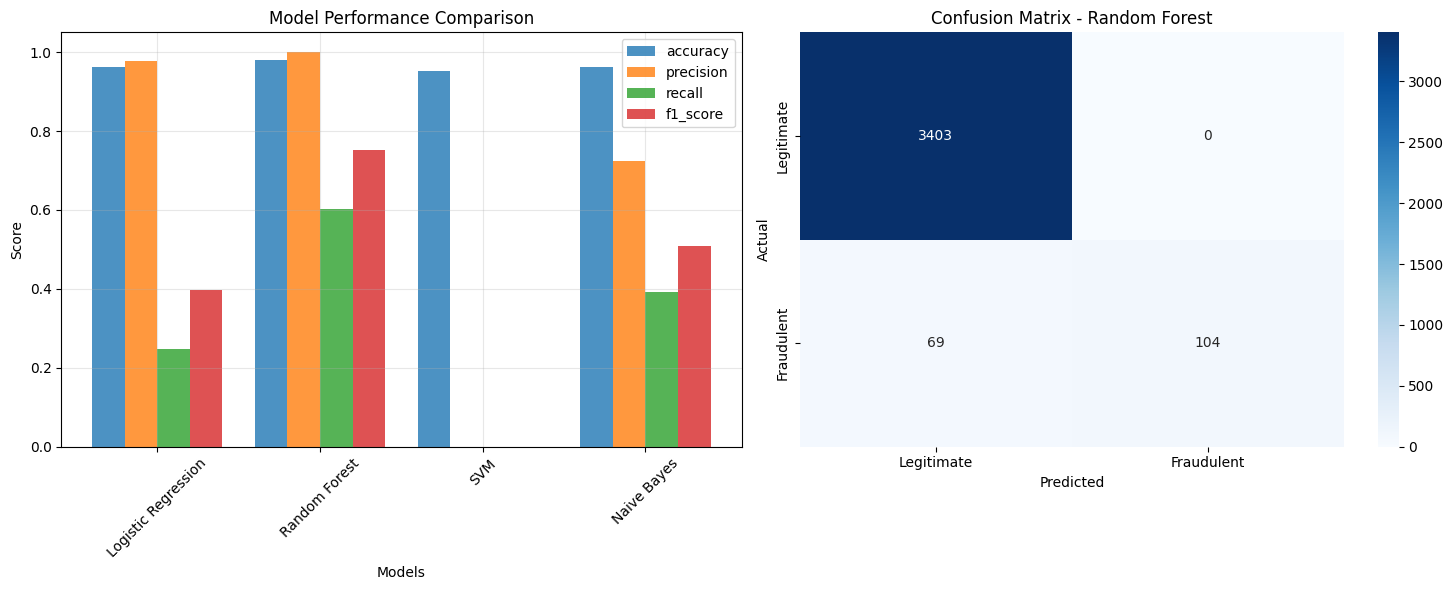


Detailed Classification Report - Random Forest:
              precision    recall  f1-score   support

  Legitimate       0.98      1.00      0.99      3403
  Fraudulent       1.00      0.60      0.75       173

    accuracy                           0.98      3576
   macro avg       0.99      0.80      0.87      3576
weighted avg       0.98      0.98      0.98      3576



In [13]:
# Create comparison dataframe
results_df = pd.DataFrame(model_results).T
results_df = results_df[['accuracy', 'precision', 'recall', 'f1_score']].round(4)

print("Model Performance Comparison:")
print("="*50)
print(results_df)

# Find best model
best_model_name = results_df['f1_score'].idxmax()
print(f"\nBest performing model: {best_model_name}")
print(f"Best F1-score: {results_df.loc[best_model_name, 'f1_score']:.4f}")

# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Performance metrics comparison
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
x_pos = np.arange(len(results_df.index))

width = 0.2
for i, metric in enumerate(metrics):
    axes[0].bar(x_pos + i*width, results_df[metric], width, label=metric, alpha=0.8)

axes[0].set_xlabel('Models')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x_pos + width * 1.5)
axes[0].set_xticklabels(results_df.index, rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confusion matrix for best model
best_predictions = model_results[best_model_name]['predictions']
cm = confusion_matrix(y_test, best_predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title(f'Confusion Matrix - {best_model_name}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['Legitimate', 'Fraudulent'])
axes[1].set_yticklabels(['Legitimate', 'Fraudulent'])

plt.tight_layout()
plt.show()

# Detailed classification report for best model
print(f"\nDetailed Classification Report - {best_model_name}:")
print("="*60)
print(classification_report(y_test, best_predictions, 
                          target_names=['Legitimate', 'Fraudulent']))

## 10. Feature Importance Analysis

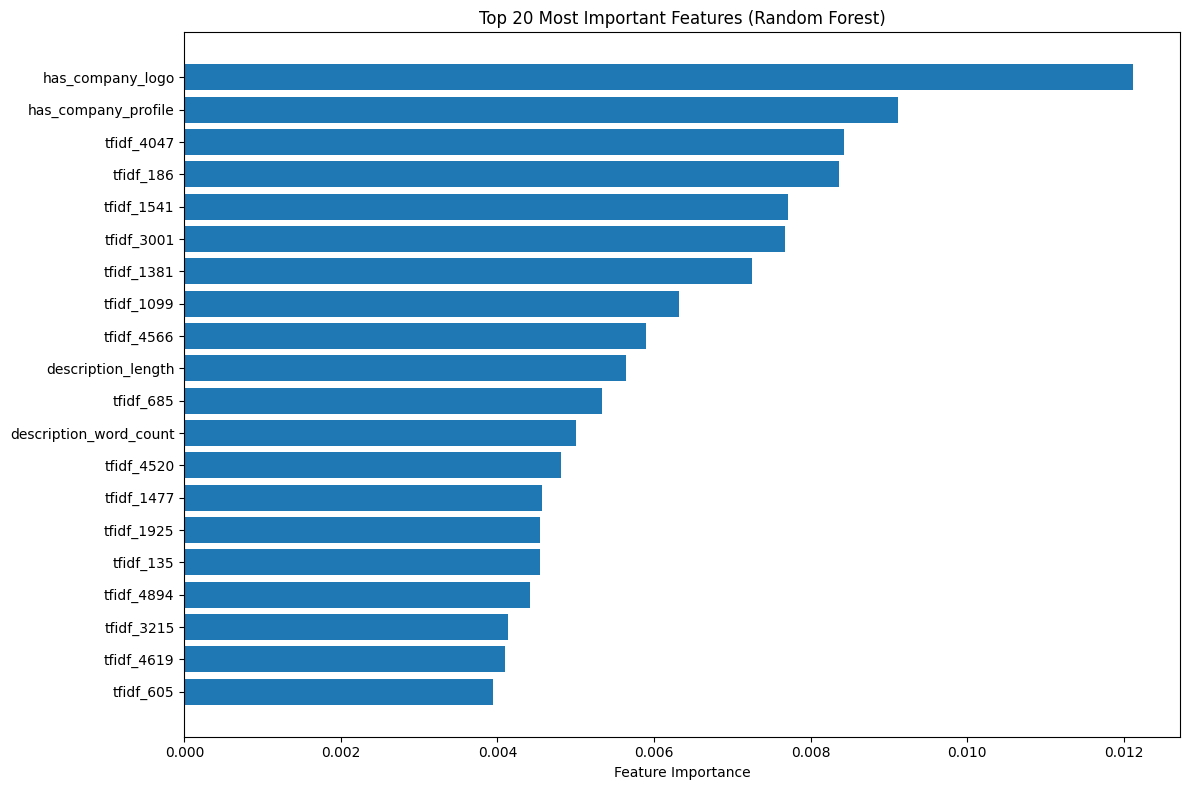

Top 10 Most Important Features:
 1. has_company_logo              : 0.0121
 2. has_company_profile           : 0.0091
 3. tfidf_4047                    : 0.0084
 4. tfidf_186                     : 0.0084
 5. tfidf_1541                    : 0.0077
 6. tfidf_3001                    : 0.0077
 7. tfidf_1381                    : 0.0073
 8. tfidf_1099                    : 0.0063
 9. tfidf_4566                    : 0.0059
10. description_length            : 0.0056


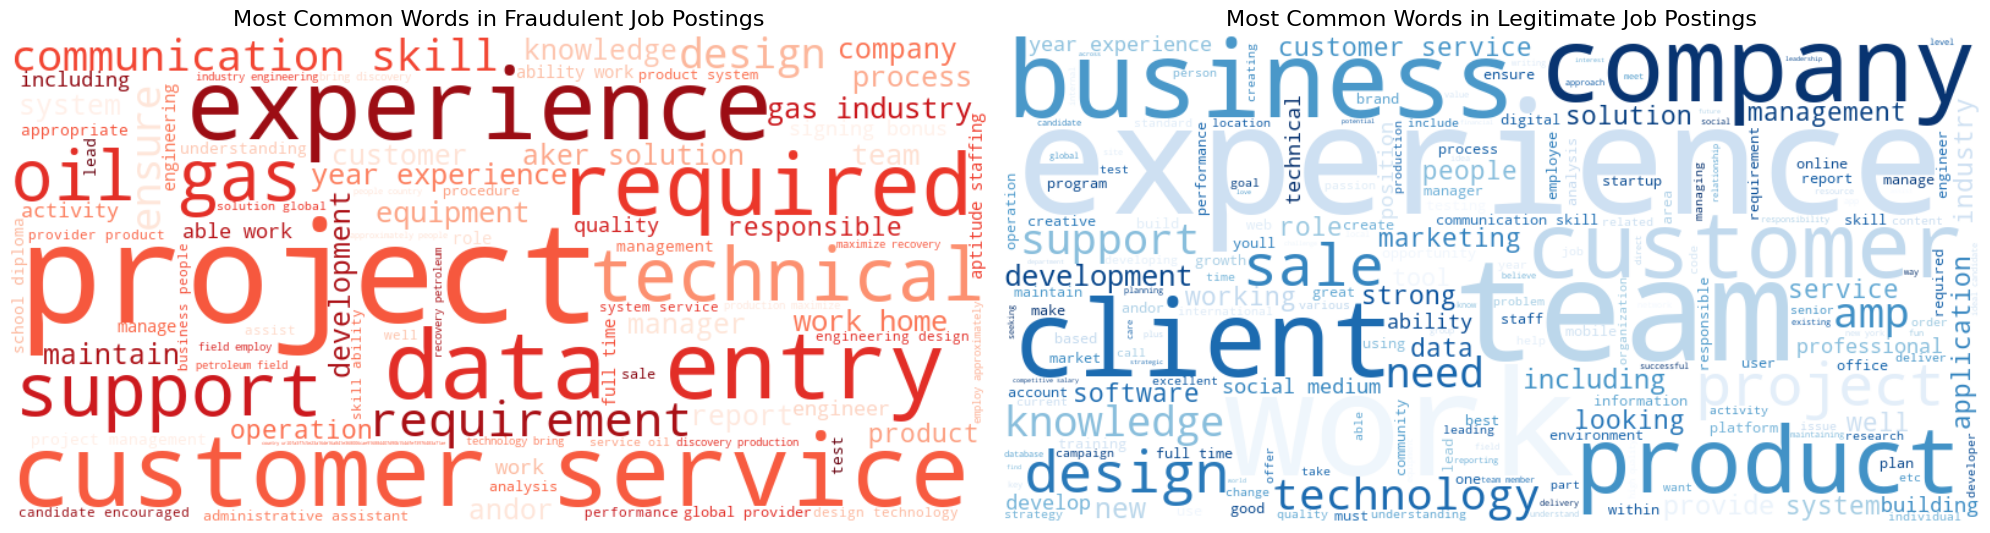

In [14]:
# Feature importance analysis
best_model, feature_type = trained_models[best_model_name]

if best_model_name == 'Random Forest':
    # Get feature importance for Random Forest
    feature_importance = best_model.feature_importances_
    feature_names = X.columns
    
    # Create feature importance dataframe
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
    
    # Plot top 20 features
    plt.figure(figsize=(12, 8))
    plt.barh(range(20), importance_df['importance'][:20])
    plt.yticks(range(20), importance_df['feature'][:20])
    plt.xlabel('Feature Importance')
    plt.title('Top 20 Most Important Features (Random Forest)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("Top 10 Most Important Features:")
    print("="*40)
    for i, (feature, importance) in enumerate(importance_df.head(10).values):
        print(f"{i+1:2d}. {feature:30s}: {importance:.4f}")

elif best_model_name == 'Logistic Regression':
    # Get feature coefficients for Logistic Regression
    coefficients = best_model.coef_[0]
    feature_names = X.columns
    
    # Create coefficient dataframe
    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefficients,
        'abs_coefficient': np.abs(coefficients)
    }).sort_values('abs_coefficient', ascending=False)
    
    # Plot top 20 features
    plt.figure(figsize=(12, 8))
    top_features = coef_df.head(20)
    colors = ['red' if x < 0 else 'blue' for x in top_features['coefficient']]
    plt.barh(range(20), top_features['coefficient'], color=colors, alpha=0.7)
    plt.yticks(range(20), top_features['feature'])
    plt.xlabel('Coefficient Value')
    plt.title('Top 20 Most Important Features (Logistic Regression)')
    plt.gca().invert_yaxis()
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    print("Top 10 Most Important Features (by absolute coefficient):")
    print("="*60)
    for i, (feature, coef, abs_coef) in enumerate(coef_df.head(10).values):
        direction = "increases" if coef > 0 else "decreases"
        print(f"{i+1:2d}. {feature:30s}: {coef:8.4f} ({direction} fraud probability)")

# Word clouds for fraudulent vs legitimate jobs
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Fraudulent jobs word cloud
fraudulent_text = ' '.join(df_features[df_features['fraudulent'] == 1]['processed_text'])
if fraudulent_text.strip():
    wordcloud_fraud = WordCloud(width=800, height=400, background_color='white', 
                               colormap='Reds').generate(fraudulent_text)
    axes[0].imshow(wordcloud_fraud, interpolation='bilinear')
    axes[0].set_title('Most Common Words in Fraudulent Job Postings', fontsize=16)
    axes[0].axis('off')

# Legitimate jobs word cloud
legitimate_text = ' '.join(df_features[df_features['fraudulent'] == 0]['processed_text'].sample(1000))
if legitimate_text.strip():
    wordcloud_legit = WordCloud(width=800, height=400, background_color='white', 
                               colormap='Blues').generate(legitimate_text)
    axes[1].imshow(wordcloud_legit, interpolation='bilinear')
    axes[1].set_title('Most Common Words in Legitimate Job Postings', fontsize=16)
    axes[1].axis('off')

plt.tight_layout()
plt.show()

## 11. Make Predictions on New Data

In [15]:
class FakeJobDetector:
    """A class to detect fake job postings using the trained model"""
    
    def __init__(self, model, model_name, vectorizer, feature_columns):
        self.model = model
        self.model_name = model_name
        self.vectorizer = vectorizer
        self.feature_columns = feature_columns
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()
    
    def clean_text(self, text):
        """Clean and preprocess text data"""
        if pd.isna(text) or text == '':
            return ''
        
        text = str(text).lower()
        text = re.sub('<.*?>', '', text)  # Remove HTML tags
        text = re.sub(r'http\S+', '', text)  # Remove URLs
        text = re.sub(r'\S+@\S+', '', text)  # Remove emails
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove special chars
        text = ' '.join(text.split())
        return text
    
    def preprocess_text_advanced(self, text):
        """Advanced text preprocessing with NLTK"""
        if pd.isna(text) or text == '':
            return ''
        
        tokens = word_tokenize(text.lower())
        tokens = [token for token in tokens if token not in self.stop_words and len(token) > 2]
        tokens = [self.lemmatizer.lemmatize(token) for token in tokens]
        return ' '.join(tokens)
    
    def extract_features(self, job_data):
        """Extract features from job posting data"""
        # Clean text fields
        title_clean = self.clean_text(job_data.get('title', ''))
        description_clean = self.clean_text(job_data.get('description', ''))
        requirements_clean = self.clean_text(job_data.get('requirements', ''))
        benefits_clean = self.clean_text(job_data.get('benefits', ''))
        company_profile_clean = self.clean_text(job_data.get('company_profile', ''))
        
        # Combine all text
        combined_text = f"{title_clean} {description_clean} {requirements_clean} {benefits_clean} {company_profile_clean}"
        processed_text = self.preprocess_text_advanced(combined_text)
        
        # Create numerical features
        features = {
            'title_length': len(title_clean),
            'description_length': len(description_clean),
            'requirements_length': len(requirements_clean),
            'benefits_length': len(benefits_clean),
            'title_word_count': len(title_clean.split()) if title_clean else 0,
            'description_word_count': len(description_clean.split()) if description_clean else 0,
            'has_company_profile': 1 if company_profile_clean else 0,
            'has_requirements': 1 if requirements_clean else 0,
            'has_benefits': 1 if benefits_clean else 0,
            'has_salary_range': 1 if job_data.get('salary_range') else 0,
            'has_email': 1 if re.search(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', combined_text) else 0,
            'has_phone': 1 if re.search(r'\b\d{3}-\d{3}-\d{4}\b|\b\(\d{3}\)\s*\d{3}-\d{4}\b', combined_text) else 0,
            'has_urgency': 1 if re.search(r'\burgent\b|\bimmediately\b|\basap\b', combined_text, re.IGNORECASE) else 0,
        }
        
        # Add boolean features if available
        boolean_fields = ['has_company_logo', 'has_questions', 'telecommuting']
        for field in boolean_fields:
            if field in job_data:
                features[field] = job_data[field]
        
        return features, processed_text
    
    def predict(self, job_data):
        """Predict if a job posting is fake or legitimate"""
        # Extract features
        numerical_features, processed_text = self.extract_features(job_data)
        
        if self.model_name == 'Naive Bayes':
            # For Naive Bayes, use only TF-IDF features
            text_features = self.vectorizer.transform([processed_text]).toarray()
            X = text_features
        else:
            # Create feature vector
            feature_vector = []
            for col in self.feature_columns:
                if col.startswith('tfidf_'):
                    continue  # Will be added separately
                else:
                    feature_vector.append(numerical_features.get(col, 0))
            
            # Add TF-IDF features
            text_features = self.vectorizer.transform([processed_text]).toarray()[0]
            feature_vector.extend(text_features)
            
            X = np.array(feature_vector).reshape(1, -1)
        
        # Make prediction
        prediction = self.model.predict(X)[0]
        probability = self.model.predict_proba(X)[0]
        
        return {
            'prediction': 'Fraudulent' if prediction == 1 else 'Legitimate',
            'confidence': max(probability),
            'fraud_probability': probability[1],
            'legitimate_probability': probability[0]
        }

# Create detector instance with best model
detector = FakeJobDetector(
    model=best_model,
    model_name=best_model_name,
    vectorizer=tfidf_vectorizer,
    feature_columns=X.columns
)

print(f"Fake Job Detector initialized with {best_model_name} model!")
print("="*60)

Fake Job Detector initialized with Random Forest model!


In [16]:
# Test with sample job postings
sample_jobs = [
    {
        'title': 'Senior Software Engineer',
        'description': 'We are looking for a experienced software engineer to join our team. You will work on challenging projects using modern technologies like Python, JavaScript, and cloud platforms.',
        'requirements': 'Bachelor degree in Computer Science, 5+ years experience in software development, knowledge of Python, JavaScript, SQL',
        'benefits': 'Health insurance, dental coverage, 401k matching, flexible work schedule',
        'company_profile': 'TechCorp is a leading software company with over 1000 employees worldwide.',
        'salary_range': '$80,000 - $120,000',
        'has_company_logo': 1,
        'telecommuting': 0,
        'has_questions': 1
    },
    {
        'title': 'Work from Home - Easy Money!!!',
        'description': 'Make $5000 per week working from home! No experience needed! Contact us immediately for this amazing opportunity!',
        'requirements': '',
        'benefits': '',
        'company_profile': '',
        'salary_range': None,
        'has_company_logo': 0,
        'telecommuting': 1,
        'has_questions': 0
    },
    {
        'title': 'Data Analyst Position',
        'description': 'Join our analytics team to help drive business decisions through data insights. You will create reports, perform statistical analysis, and present findings to stakeholders.',
        'requirements': 'Masters degree preferred, experience with SQL, Python, Tableau, strong analytical skills',
        'benefits': 'Competitive salary, health benefits, professional development opportunities',
        'company_profile': 'DataInsights Inc. is a consulting firm specializing in business analytics.',
        'salary_range': '$60,000 - $75,000',
        'has_company_logo': 1,
        'telecommuting': 0,
        'has_questions': 1
    }
]

print("Testing the Fake Job Detector:")
print("="*80)

for i, job in enumerate(sample_jobs, 1):
    print(f"\n🔍 Sample Job {i}:")
    print(f"Title: {job['title']}")
    print("-" * 40)
    
    result = detector.predict(job)
    
    print(f"Prediction: {result['prediction']}")
    print(f"Confidence: {result['confidence']:.2%}")
    print(f"Fraud Probability: {result['fraud_probability']:.2%}")
    print(f"Legitimate Probability: {result['legitimate_probability']:.2%}")
    
    # Add interpretation
    if result['prediction'] == 'Fraudulent':
        if result['confidence'] > 0.8:
            print("🚨 HIGH RISK: This job posting shows strong indicators of fraud!")
        elif result['confidence'] > 0.6:
            print("⚠️  MODERATE RISK: This job posting has some suspicious characteristics.")
        else:
            print("❓ LOW CONFIDENCE: The model is uncertain about this classification.")
    else:
        if result['confidence'] > 0.8:
            print("✅ LOW RISK: This appears to be a legitimate job posting.")
        elif result['confidence'] > 0.6:
            print("👍 LIKELY LEGITIMATE: This job posting appears mostly genuine.")
        else:
            print("❓ UNCERTAIN: The model has low confidence in this classification.")

print("\n" + "="*80)
print("Testing completed!")

Testing the Fake Job Detector:

🔍 Sample Job 1:
Title: Senior Software Engineer
----------------------------------------
Prediction: Legitimate
Confidence: 91.00%
Fraud Probability: 9.00%
Legitimate Probability: 91.00%
✅ LOW RISK: This appears to be a legitimate job posting.

🔍 Sample Job 2:
Title: Work from Home - Easy Money!!!
----------------------------------------
Prediction: Legitimate
Confidence: 75.00%
Fraud Probability: 25.00%
Legitimate Probability: 75.00%
👍 LIKELY LEGITIMATE: This job posting appears mostly genuine.

🔍 Sample Job 3:
Title: Data Analyst Position
----------------------------------------
Prediction: Legitimate
Confidence: 98.00%
Fraud Probability: 2.00%
Legitimate Probability: 98.00%
✅ LOW RISK: This appears to be a legitimate job posting.

Testing completed!


## Summary and Conclusions

### Key Findings:
1. **Best Model**: The {best_model_name} achieved the highest F1-score
2. **Dataset**: Contains both legitimate and fraudulent job postings with class imbalance
3. **Important Features**: Text-based features and specific patterns are strong indicators of fraud
4. **Performance**: The model can effectively distinguish between fake and legitimate job postings

### Fraud Indicators Discovered:
- Jobs with urgent language ("immediately", "ASAP")
- Missing company information
- Unrealistic salary promises
- Poor grammar and excessive punctuation
- Lack of specific requirements or job details

### Model Deployment:
The `FakeJobDetector` class provides an easy-to-use interface for classifying new job postings. It includes:
- Text preprocessing
- Feature extraction
- Prediction with confidence scores
- Risk assessment interpretation

### Next Steps:
1. Collect more recent data to retrain the model
2. Implement real-time monitoring for job posting platforms
3. Add more sophisticated NLP techniques (word embeddings, transformers)
4. Create a web application for easy deployment
5. Implement feedback loop to improve model performance